# Correlaciones

Este taller tiene como objetivo hacer un acercamiento práctico al análisis de correlaciones y una introducción al análisis de regresión.

In [2]:
from scipy import stats
import scipy
import statsmodels.api as sm
import statsmodels.formula.api as smf

In [3]:
import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib as mpl
import matplotlib.pyplot as plt

In [4]:
!python --version
print('NumPy', np.__version__)
print('Pandas', pd.__version__)
print('Matplotlib', mpl.__version__)
print('Seaborn',sns.__version__)

Python 3.13.5
NumPy 2.1.3
Pandas 2.2.3
Matplotlib 3.10.0
Seaborn 0.13.2


In [5]:
# Carga de datos
# para este ejemplo se usara el set de iris.data

variables = ['sepal_length','sepal_width','petal_length','petal_width','species']
iris = pd.read_csv('https://archive.ics.uci.edu/ml/machine-learning-databases/iris/iris.data', names= variables)

In [6]:
iris.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 150 entries, 0 to 149
Data columns (total 5 columns):
 #   Column        Non-Null Count  Dtype  
---  ------        --------------  -----  
 0   sepal_length  150 non-null    float64
 1   sepal_width   150 non-null    float64
 2   petal_length  150 non-null    float64
 3   petal_width   150 non-null    float64
 4   species       150 non-null    object 
dtypes: float64(4), object(1)
memory usage: 6.0+ KB


## **1. Análisis de correlación**

Este es un tipo de análisis estadístico usado para medir la fortaleza de relaciones lineas entre dos variables y medir su grado de asociación. Esto se logra calculando coeficientes de correlación que permiten cuantificar el grado de asociación entre dos variables.

### **3.1 Coeficientes de correlación**

Los coeficientes toman valores entre -1.0 y 1.0. Toman valores positivos cuando las variables son directamente proporcionales, y valores negativos cuando la relación entre las variables es inversamente proporcional. La fortaleza de la correlación se incrementa hacía los extremos -1.0 y 1.0, y es más débil cuando se acerca a 0.

Existen 3 tipos de coeficientes de correlación

* **Coeficiente de correlación $r$ de Pearson**: Este es el coeficiente de correlación más conocido y ampliamente utilizado. Es útil para el análisis de variables cuantitativas. Este es un método parámetrico, eso quiere decir que parte de varios supuestos sobre las variables analizadas, como la normalidad de las variables y la homegeneidad de varianzas.
* **Coeficientes de correlación $\rho$ de Spearman**: Es un método no paramétrico, puede ser utilizado con variables categóricas ordinales o variables numéricas. Las variables pueden no ser normales y puede no haber homogeneidad de varianzas.
* **Coeficiente de correlación $\tau$ de Kendall**:
Este tmabién es un método no parámetrico empleado para variables categóricas ordinales. Evalua relaciones monotónicas entre las variables analizadas. Es computacionalmente más costoso.

### Pandas 

Se puede hacer análisis de correlación empleando pandas, numpy o scipy. Empezaremos con los métodos más básicos usando pandas.

* `pd.Series.corr`: Permite calcular el coeficiente de correlación de una serie con otra.
* `pd.DataFrame.corrwith`: Calula correlación entre las filas o columnas de un DataFrame contra las filas o columnas de una Series u otro DataFrame.

* `pd.Dataframe.corr`: Calcula la matriz de correlación entre las columnas de un DataFrame.

Todos estos métodos pueden trabajar con los métodos `'pearson', 'kendall', 'spearman'`, por defecto si no se epecífica se trabaja con **pearson**.




In [7]:
np.random.seed(1) # Semilla para que genere los mismos estados aleatorias

v1 = pd.Series(range(100)) # recuerde range inicia desde 0 y por defecto va de uno a uno
v2 = pd.Series(range(100,0,-1))

# Generación de números enteros aleatorios
v3 = pd.Series(np.random.randint(0,100,100)) # valor minimo, valor maximo, cantidad de números
v4 = pd.Series(np.random.randint(0,100,100))

datos = pd.DataFrame(data={'v1':v1, 
                           'v2':v2,
                           'v3':v3,
                           'v4':v4, })

datos

,v1,v2,v3,v4
0,0,100,37,0
1,1,99,12,77
2,2,98,72,6
3,3,97,9,52
4,4,96,75,85
...,...,...,...,...
95,95,5,23,77
96,96,4,55,91
97,97,3,65,49
98,98,2,77,47


In [8]:
# Esta función nos va a ayudar a ahorrar código
# Va a graficar la relación entre un par de variables presentes en el mismo dataframe
# También va a calcular el coeficiente de correlación de pearson y va a mostrarlo

def graficar_correlacion(df, var_a, var_b, meth="pearson"):

  coef = df[var_a].corr(df[var_b], method=meth); # Calcula el coeficiente de correlacion

  fig, axes = plt.subplots(dpi = 110);
  
  sns.scatterplot(data = df,
                  x = var_a, y = var_b, 
                 
                  ax = axes,
                  marker='o', 
                  linestyle='None', 
                  s = 50,  # tamaño de los puntos
                  alpha = 0.5,  # grado de transparencia
                  ); 

  axes.set_title(f"Coeficiente de correlación: {coef :.2}") # titulo con formateo de string

In [9]:
# Correlación perfecta positiva - relación directa, entre v1 y v1

r = v1.corr(v1)
r

np.float64(0.9999999999999999)

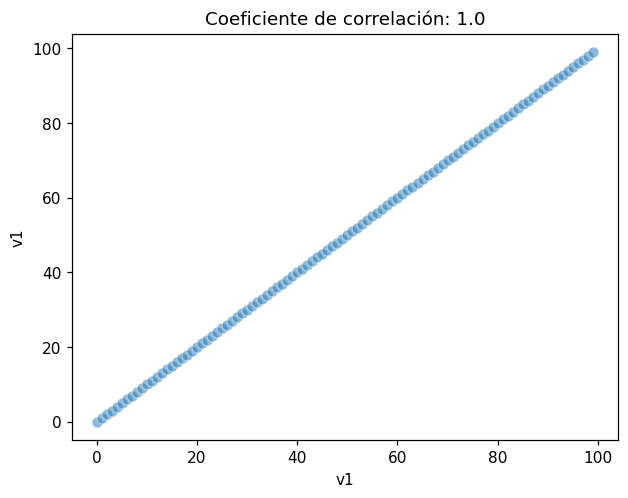

In [10]:
# Es valioso y además recomendado acompañar el cálculo de coeficientes de correlación con visualización

graficar_correlacion(datos,'v1','v1')

In [11]:
# Correlación perfecta negativa, relación inversa entre V1 y V2

r = v1.corr(v2)
r

np.float64(-0.9999999999999999)

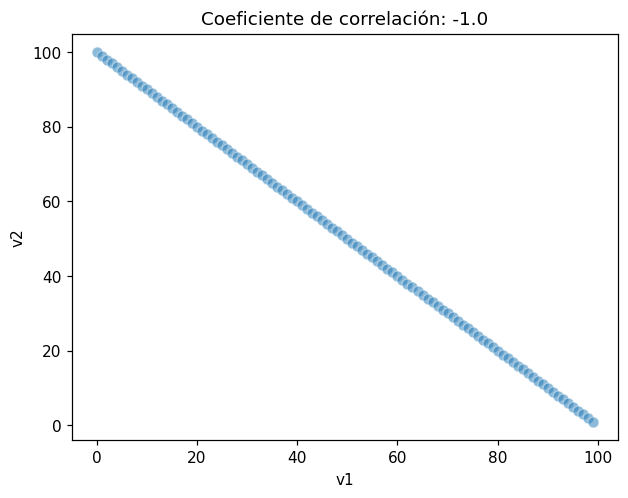

In [12]:
graficar_correlacion(datos,'v1','v2')

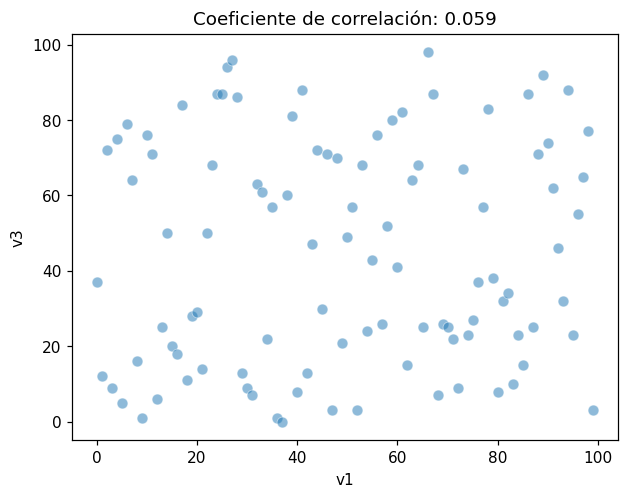

In [13]:
graficar_correlacion(datos,'v1','v3')

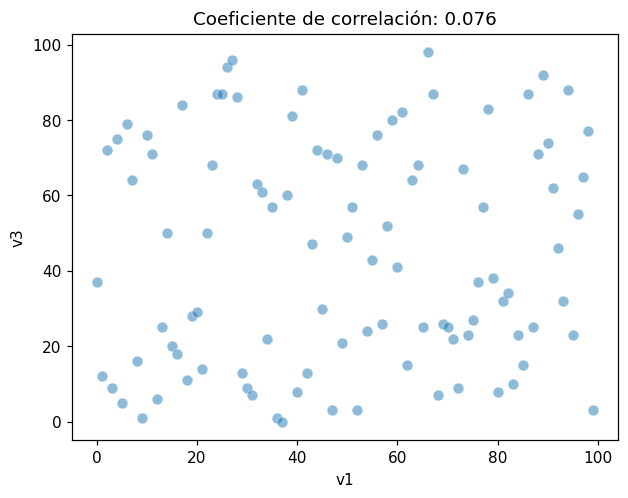

In [14]:
graficar_correlacion(datos,'v1','v3', 'spearman')

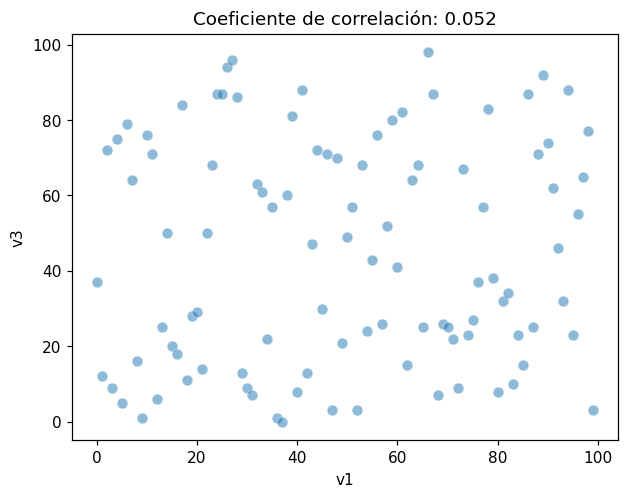

In [15]:
graficar_correlacion(datos,'v1','v3', 'kendall')

## Matriz de correlacion

Este método es muy valioso porque permite evaluar la correlación entre cada par de variables presentes en el dataset. La matriz obtenida es simétrica ya que el coeficiente de correlación no depende del orden.

Los valores van desde el -1 pasando por el cero hasta el 1, donde -1 y 1 indican correlaciones fuertes y el valor de cero que no existe correlacion

In [16]:
# En este codigo calculo la matriz de correlacion entre todas las variables de mi data frame
a = datos.corr()
a

,v1,v2,v3,v4
v1,1.000000,-1.000000,0.058680,0.022354
v2,-1.000000,1.000000,-0.058680,-0.022354
v3,0.058680,-0.058680,1.000000,-0.064611
v4,0.022354,-0.022354,-0.064611,1.000000


<Axes: >

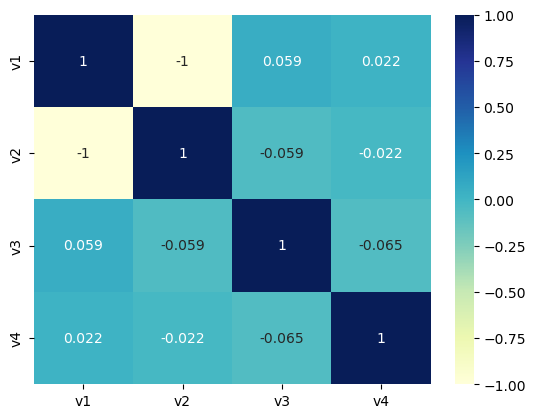

In [17]:
sns.heatmap(data = a,
            vmin = -1,
            vmax = 1,
            center = 0,
            annot = True,
            cmap="YlGnBu"
            )

### Practica Housing

In [18]:
# Importamos la informacion de housing
housing = pd.read_csv("https://raw.githubusercontent.com/HarryVargas96/UdeCataluna/main/Housing.csv")

In [19]:
housing.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 545 entries, 0 to 544
Data columns (total 13 columns):
 #   Column            Non-Null Count  Dtype 
---  ------            --------------  ----- 
 0   price             545 non-null    int64 
 1   area              545 non-null    int64 
 2   bedrooms          545 non-null    int64 
 3   bathrooms         545 non-null    int64 
 4   stories           545 non-null    int64 
 5   mainroad          545 non-null    object
 6   guestroom         545 non-null    object
 7   basement          545 non-null    object
 8   hotwaterheating   545 non-null    object
 9   airconditioning   545 non-null    object
 10  parking           545 non-null    int64 
 11  prefarea          545 non-null    object
 12  furnishingstatus  545 non-null    object
dtypes: int64(6), object(7)
memory usage: 55.5+ KB


In [20]:
# hacemos una descripcion estadistica de las variables de data-set
housing.describe()

,price,area,bedrooms,bathrooms,stories,parking
count,5.450000e+02,545.000000,545.000000,545.000000,545.000000,545.000000
mean,4.766729e+06,5150.541284,2.965138,1.286239,1.805505,0.693578
std,1.870440e+06,2170.141023,0.738064,0.502470,0.867492,0.861586
min,1.750000e+06,1650.000000,1.000000,1.000000,1.000000,0.000000
25%,3.430000e+06,3600.000000,2.000000,1.000000,1.000000,0.000000
50%,4.340000e+06,4600.000000,3.000000,1.000000,2.000000,0.000000
75%,5.740000e+06,6360.000000,3.000000,2.000000,2.000000,1.000000
max,1.330000e+07,16200.000000,6.000000,4.000000,4.000000,3.000000


In [21]:
# Descripcion de las variables categoricas
housing.describe(include='object')

,mainroad,guestroom,basement,hotwaterheating,airconditioning,prefarea,furnishingstatus
count,545,545,545,545,545,545,545
unique,2,2,2,2,2,2,3
top,yes,no,no,no,no,no,semi-furnished
freq,468,448,354,520,373,417,227


In [22]:
# Evaluamos la correlacion entre las variables
corr_calc = housing.corr(numeric_only=True)
corr_calc

,price,area,bedrooms,bathrooms,stories,parking
price,1.000000,0.535997,0.366494,0.517545,0.420712,0.384394
area,0.535997,1.000000,0.151858,0.193820,0.083996,0.352980
bedrooms,0.366494,0.151858,1.000000,0.373930,0.408564,0.139270
bathrooms,0.517545,0.193820,0.373930,1.000000,0.326165,0.177496
stories,0.420712,0.083996,0.408564,0.326165,1.000000,0.045547
parking,0.384394,0.352980,0.139270,0.177496,0.045547,1.000000


<Axes: >

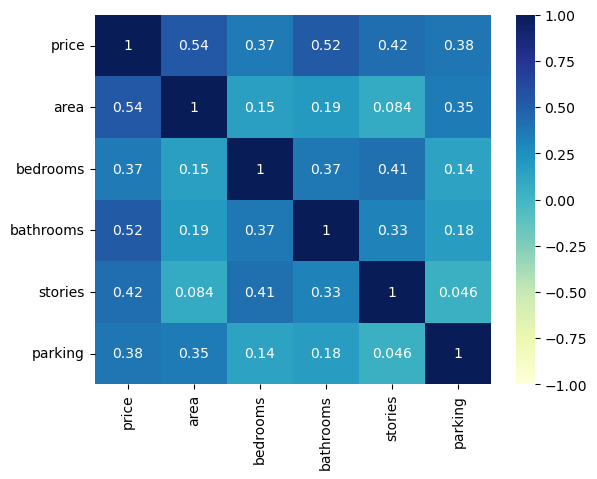

In [23]:
sns.heatmap(
    data= corr_calc,
    vmin= -1,
    vmax=1,
    center=0,
    annot = True,
    cmap="YlGnBu"
)

'\nAl comparar en un grafico de dispercion el area y el precio de los apartamentos tiene \nun comportameinto creciente en el precio a pesar de tener una misma area o un area similar\n\n-> En estos casos es importante recordadr que hay otras variables como\n(ubicacion, estado de la vivienda, estado de las calles ...) que pueden\ninfluir de forma directa en el precio de la vivienda\n'

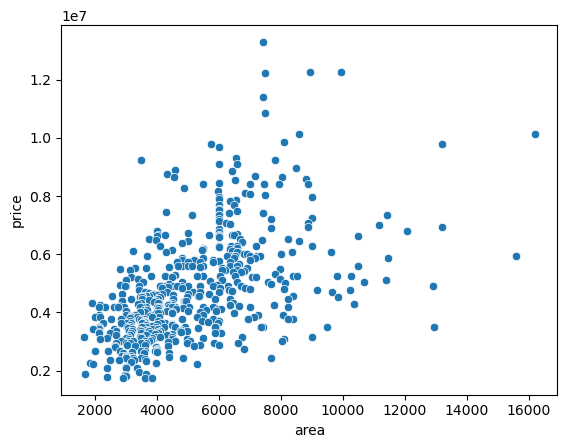

In [24]:
# Segun la matriz de correlacion, tenemos una correlacion positiva o directa entre precio y area

sns.scatterplot(
    data= housing,
    x= 'area',
    y= 'price'
)

'''
Al comparar en un grafico de dispercion el area y el precio de los apartamentos tiene 
un comportameinto creciente en el precio a pesar de tener una misma area o un area similar

-> En estos casos es importante recordadr que hay otras variables como
(ubicacion, estado de la vivienda, estado de las calles ...) que pueden
influir de forma directa en el precio de la vivienda
'''

<Axes: xlabel='parking', ylabel='price'>

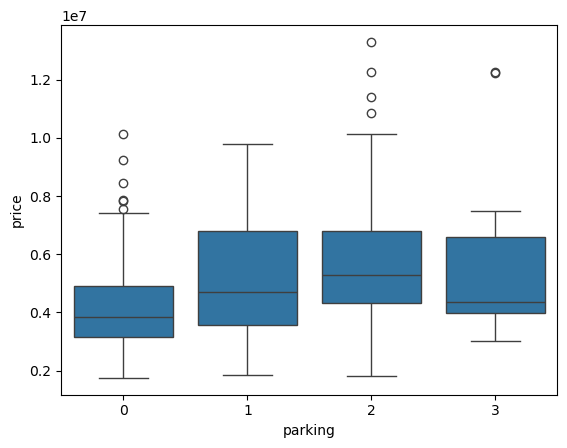

In [25]:
sns.boxplot(
    data= housing,
    x= 'parking',
    y= 'price'
)

In [26]:
housing['parking'].value_counts()

parking
0    299
1    126
2    108
3     12
Name: count, dtype: int64